# Phase 2 — Structure de coût & cadrage métier

Dans ce notebook, on ne construit pas de cible (le label `Class` est donné).
L'objectif est de **formaliser la structure de coût** qui pilotera :
- le choix du seuil de décision (Phase 9)
- la pondération des exemples lors de l'entraînement (Phase 7)
- l'évaluation finale en € (Phase 9)

## Plan
1. Rappel des chiffres EDA
2. Matrice de coût formelle
3. Distribution des montants fraudés
4. Scénarios de référence (worst / random / perfect)
5. Fonction `compute_cost` et validation
6. Analyse de sensibilité sur le coût FP
7. Décisions finales

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.config import (
    RAW_DATA_PATH, RANDOM_SEED,
    COST_FALSE_POSITIVE, TOTAL_FRAUD_AMOUNT,
    N_FRAUDS, N_LEGIT
)

np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(exist_ok=True)

# Chargement des données (pour les montants réels)
df = pd.read_csv(RAW_DATA_PATH)
df = df.drop_duplicates()   # Suppression des 1 081 doublons (décision Phase 1)
print(f'Dataset chargé : {len(df):,} lignes après suppression des doublons')

Dataset chargé : 283,726 lignes après suppression des doublons


## 1. Rappel des chiffres EDA

> Ces chiffres proviennent du notebook `01_eda.ipynb` et servent de référence pour calibrer la structure de coût.

In [2]:
frauds  = df[df['Class'] == 1]
legits  = df[df['Class'] == 0]

print('=== Chiffres de référence ===')
print(f'Transactions totales      : {len(df):>10,}')
print(f'Fraudes                   : {len(frauds):>10,}  ({len(frauds)/len(df)*100:.3f} %)')
print(f'Légitimes                 : {len(legits):>10,}')
print(f'Ratio                     : 1 fraude / {len(legits)//len(frauds):,} légitimes')
print()
print(f'Montant total fraudé      : {frauds["Amount"].sum():>10,.2f} €')
print(f'Montant médian fraude     : {frauds["Amount"].median():>10.2f} €')
print(f'Montant moyen fraude      : {frauds["Amount"].mean():>10.2f} €')
print(f'Montant max fraude        : {frauds["Amount"].max():>10.2f} €')
print(f'Montant médian légit      : {legits["Amount"].median():>10.2f} €')

=== Chiffres de référence ===
Transactions totales      :    283,726
Fraudes                   :        473  (0.167 %)
Légitimes                 :    283,253
Ratio                     : 1 fraude / 598 légitimes

Montant total fraudé      :  58,591.39 €
Montant médian fraude     :       9.82 €
Montant moyen fraude      :     123.87 €
Montant max fraude        :    2125.87 €
Montant médian légit      :      22.00 €


## 2. Matrice de coût formelle

### Définitions

| | Prédit : Légit (0) | Prédit : Fraude (1) |
|---|---|---|
| **Réel : Légit (0)** | ✅ Vrai Négatif — coût = **0 €** | ⚠️ Faux Positif — coût = **C_FP** |
| **Réel : Fraude (1)** | ❌ Faux Négatif — coût = **`Amount`** | ✅ Vrai Positif — coût = **0 €** |

### Hypothèses

**Coût d'un Faux Négatif (FN)** = montant de la transaction fraudée (`Amount`)  
→ La fraude passe, le client est débité, la banque rembourse : coût ≈ `Amount`

**Coût d'un Faux Positif (FP)** = `C_FP` (coût fixe, paramétrable)  
→ Transaction légitime bloquée : friction client + coût d'un analyste pour traitement manuel  
→ Valeur par défaut dans `config.py` : **5 €** (hypothèse conservatrice — à calibrer avec le métier)

> ⚠️ **Limite** : cette matrice est une approximation. Dans la réalité, le coût FP peut varier  
> (client VIP bloqué = coût de rétention élevé). Ces hypothèses doivent être validées avec l'équipe Risque.

C:\Users\LOG\AppData\Local\Temp\ipykernel_23076\381887440.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig(REPORTS_DIR / 'fig07_cost_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\LOG\AppData\Local\Temp\ipykernel_23076\381887440.py:25: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(REPORTS_DIR / 'fig07_cost_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\LOG\AppData\Local\Temp\ipykernel_23076\381887440.py:25: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(REPORTS_DIR / 'fig07_cost_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\LOG\AppData\Local\Temp\ipykernel_23076\381887440.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig(REPORTS_DIR / 'fig07_cost_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\LOG\OneDrive - SUPCOM\Bureau\Projet data science\credit card fraud detection\Credit-Card-Fraud-D

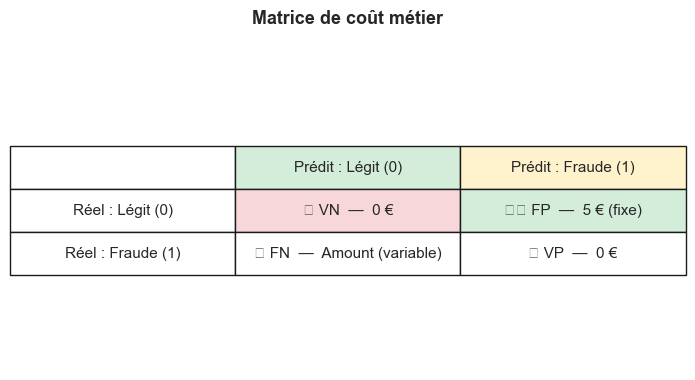

In [3]:
# Visualisation de la matrice de coût
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table_data = [
    ['', 'Prédit : Légit (0)', 'Prédit : Fraude (1)'],
    ['Réel : Légit (0)', '✅ VN  —  0 €', f'⚠️ FP  —  {COST_FALSE_POSITIVE:.0f} € (fixe)'],
    ['Réel : Fraude (1)', '❌ FN  —  Amount (variable)', '✅ VP  —  0 €'],
]

t = ax.table(cellText=table_data[1:], colLabels=table_data[0],
             loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1.5, 2.5)

# Colorier les cellules
t[0, 1].set_facecolor('#d4edda')  # VN vert
t[0, 2].set_facecolor('#fff3cd')  # FP orange
t[1, 1].set_facecolor('#f8d7da')  # FN rouge
t[1, 2].set_facecolor('#d4edda')  # VP vert

ax.set_title('Matrice de coût métier', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig07_cost_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Distribution des montants fraudés

La distribution de `Amount` pour les fraudes justifie pourquoi le coût FN est **variable**  
et non fixe : une fraude à 25 000 € n'a pas le même impact qu'une à 1 €.

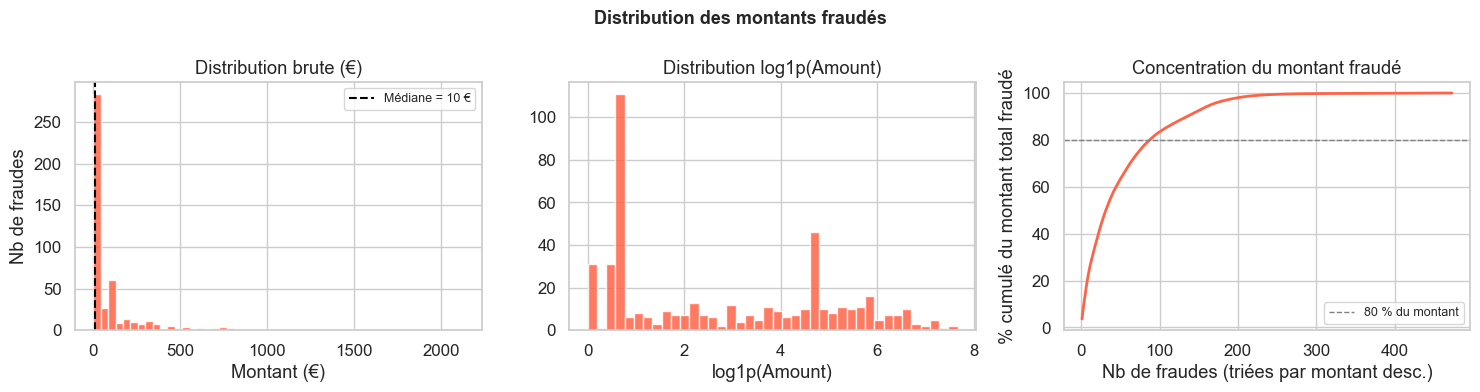

88 fraudes sur 473 couvrent 80 % du montant total fraudé
Soit les 18.6 % de fraudes les plus importantes en valeur


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

amounts = frauds['Amount']

# Histogramme brut
axes[0].hist(amounts, bins=50, color='tomato', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution brute (€)')
axes[0].set_xlabel('Montant (€)')
axes[0].set_ylabel('Nb de fraudes')
axes[0].axvline(amounts.median(), color='black', linestyle='--', label=f'Médiane = {amounts.median():.0f} €')
axes[0].legend(fontsize=9)

# Histogramme log
axes[1].hist(np.log1p(amounts), bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution log1p(Amount)')
axes[1].set_xlabel('log1p(Amount)')

# Courbe cumulative du montant fraudé
sorted_amounts = amounts.sort_values(ascending=False).reset_index(drop=True)
cumul = sorted_amounts.cumsum() / sorted_amounts.sum() * 100
axes[2].plot(range(1, len(cumul)+1), cumul.values, color='tomato', linewidth=2)
axes[2].axhline(80, color='gray', linestyle='--', linewidth=1, label='80 % du montant')
axes[2].set_title('Concentration du montant fraudé')
axes[2].set_xlabel('Nb de fraudes (triées par montant desc.)')
axes[2].set_ylabel('% cumulé du montant total fraudé')
axes[2].legend(fontsize=9)

plt.suptitle('Distribution des montants fraudés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig08_fraud_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Concentration : combien de fraudes couvrent 80% du montant ?
n_80 = (cumul <= 80).sum() + 1
print(f'{n_80} fraudes sur {len(amounts)} couvrent 80 % du montant total fraudé')
print(f'Soit les {n_80/len(amounts)*100:.1f} % de fraudes les plus importantes en valeur')

## 4. Scénarios de référence

Avant d'entraîner quoi que ce soit, on pose 3 scénarios de référence pour calibrer  
ce que le modèle doit battre et ce qu'il peut espérer atteindre.

In [5]:
total_fraud_amount = frauds['Amount'].sum()
n_frauds = len(frauds)
n_legits  = len(legits)
n_total   = len(df)

def compute_cost(y_true, y_pred, amounts, cost_fp=COST_FALSE_POSITIVE):
    """
    Calcule le coût total d'une politique de décision.
    
    Paramètres
    ----------
    y_true   : array-like — labels réels (0/1)
    y_pred   : array-like — prédictions binaires (0/1)
    amounts  : array-like — montants des transactions
    cost_fp  : float — coût fixe par faux positif (€)

    Retourne
    --------
    dict avec coût total, coût FN, coût FP, montant récupéré, nb FN, nb FP
    """
    y_true  = np.asarray(y_true)
    y_pred  = np.asarray(y_pred)
    amounts = np.asarray(amounts)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    tp_mask = (y_true == 1) & (y_pred == 1)

    cost_fn_total = amounts[fn_mask].sum()
    cost_fp_total = fp_mask.sum() * cost_fp
    recovered     = amounts[tp_mask].sum()

    return {
        'cout_total'    : cost_fn_total + cost_fp_total,
        'cout_fn'       : cost_fn_total,
        'cout_fp'       : cost_fp_total,
        'montant_recupere': recovered,
        'n_fn'          : fn_mask.sum(),
        'n_fp'          : fp_mask.sum(),
        'n_tp'          : tp_mask.sum(),
        'pct_recupere'  : recovered / total_fraud_amount * 100 if total_fraud_amount > 0 else 0
    }

y_true   = df['Class'].values
amounts  = df['Amount'].values

# Scénario 1 : pire cas — on ne détecte aucune fraude
worst = compute_cost(y_true, np.zeros(n_total, dtype=int), amounts)

# Scénario 2 : aléatoire — on bloque 50 % des transactions au hasard
np.random.seed(RANDOM_SEED)
random_pred = np.random.randint(0, 2, size=n_total)
random_case = compute_cost(y_true, random_pred, amounts)

# Scénario 3 : modèle parfait — on détecte toutes les fraudes sans FP
perfect = compute_cost(y_true, y_true.copy(), amounts)

print('='*60)
print(f'{"Scénario":<25} {"Coût total":>12} {"Coût FN":>10} {"Coût FP":>10} {"% récupéré":>12}')
print('-'*60)
for name, s in [('Pire cas (0 détection)', worst),
                ('Aléatoire (50 %)', random_case),
                ('Modèle parfait', perfect)]:
    print(f'{name:<25} {s["cout_total"]:>11,.0f}€ {s["cout_fn"]:>9,.0f}€ '
          f'{s["cout_fp"]:>9,.0f}€ {s["pct_recupere"]:>11.1f}%')
print('='*60)
print(f'\nMontant total fraudé : {total_fraud_amount:,.2f} €')
print(f'Objectif du modèle   : s\'approcher du modèle parfait (0 € de coût total)')

Scénario                    Coût total    Coût FN    Coût FP   % récupéré
------------------------------------------------------------
Pire cas (0 détection)         58,591€    58,591€         0€         0.0%
Aléatoire (50 %)              742,827€    33,962€   708,865€        42.0%
Modèle parfait                      0€         0€         0€       100.0%

Montant total fraudé : 58,591.39 €
Objectif du modèle   : s'approcher du modèle parfait (0 € de coût total)


## 5. Analyse de sensibilité sur le coût FP

Le coût d'un faux positif (`C_FP = 5 €`) est une **hypothèse** à valider avec le métier.  
On montre ici comment le coût optimal évolue selon cette valeur.

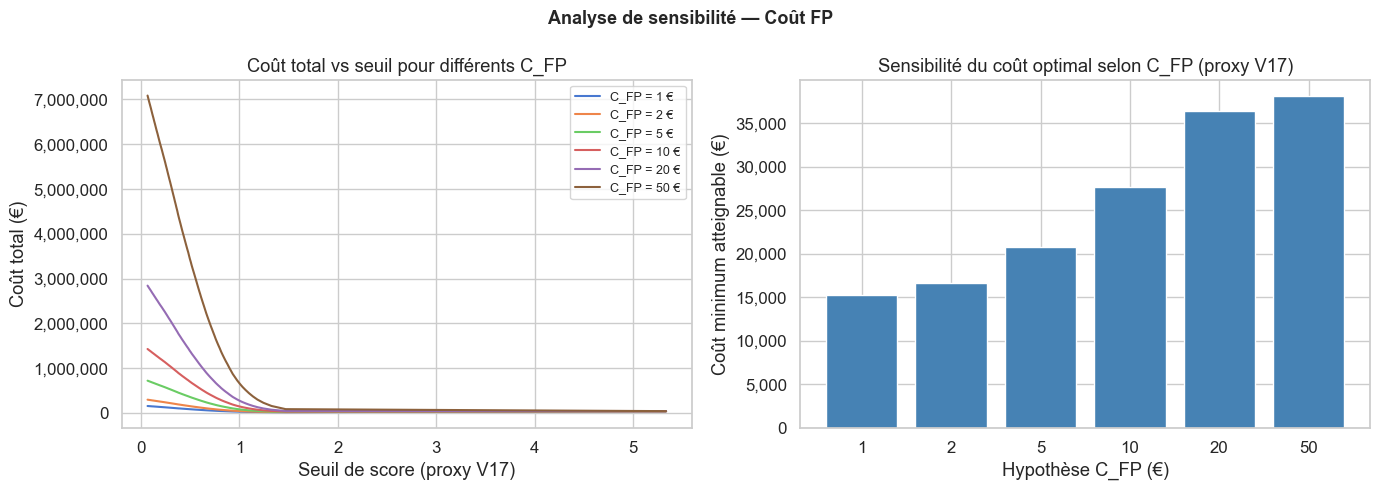

Avec C_FP = 5.0 € (hypothèse config.py) :
  Coût pire cas        : 58,591 €
  Coût modèle parfait  : 0 €
  Gain max atteignable : 58,591 €


In [6]:
# Simuler un modèle naïf qui bloque les X % de transactions les plus risquées
# en utilisant V17 (feature la plus discriminante) comme score proxy
scores_proxy = -df['V17'].values   # V17 corrélée négativement avec fraude

cfp_values   = [1, 2, 5, 10, 20, 50]
thresholds   = np.percentile(scores_proxy, np.linspace(50, 99.9, 100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cfp in cfp_values:
    costs = []
    for thr in thresholds:
        pred = (scores_proxy >= thr).astype(int)
        c = compute_cost(y_true, pred, amounts, cost_fp=cfp)
        costs.append(c['cout_total'])
    axes[0].plot(thresholds, costs, label=f'C_FP = {cfp} €', linewidth=1.5)

axes[0].set_xlabel('Seuil de score (proxy V17)')
axes[0].set_ylabel('Coût total (€)')
axes[0].set_title('Coût total vs seuil pour différents C_FP')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Coût minimum atteignable selon C_FP
min_costs = []
for cfp in cfp_values:
    costs = []
    for thr in thresholds:
        pred = (scores_proxy >= thr).astype(int)
        c = compute_cost(y_true, pred, amounts, cost_fp=cfp)
        costs.append(c['cout_total'])
    min_costs.append(min(costs))

axes[1].bar([str(c) for c in cfp_values], min_costs, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Hypothèse C_FP (€)')
axes[1].set_ylabel('Coût minimum atteignable (€)')
axes[1].set_title('Sensibilité du coût optimal selon C_FP (proxy V17)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Analyse de sensibilité — Coût FP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig09_cost_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avec C_FP = {COST_FALSE_POSITIVE} € (hypothèse config.py) :')
print(f'  Coût pire cas        : {worst["cout_total"]:,.0f} €')
print(f'  Coût modèle parfait  : {perfect["cout_total"]:,.0f} €')
print(f'  Gain max atteignable : {worst["cout_total"] - perfect["cout_total"]:,.0f} €')

## 6. Conclusions & décisions

### Chiffres clés issus de l'exécution

| Indicateur | Valeur | Note |
|---|---|---|
| Transactions après dédoublonnage | **283 726** | 1 081 doublons supprimés |
| Fraudes (après doublons) | **473 (0,167 %)** | Correction vs EDA : certains doublons étaient des fraudes |
| Légitimes | **283 253** | |
| Ratio | **1 fraude / 598 légitimes** | Plus déséquilibré qu'estimé en Phase 1 |
| Montant total fraudé | **58 591,39 €** | Référence coût pour Phase 9 |
| Montant médian fraude | **9,82 €** | Fraudes de faible montant majoritaires |
| Montant moyen fraude | **123,87 €** | Moyenne tirée vers le haut par quelques grosses fraudes |
| Montant max fraude | **2 125,87 €** | Bien inférieur au max global Amount (25 691 €) |
| Concentration | **88 fraudes = 80 % du montant** | Soit 18,6 % des fraudes en valeur |

### Scénarios de référence

| Scénario | Coût total | Coût FN | Coût FP | % récupéré |
|---|---|---|---|---|
| Pire cas (0 détection) | **58 591 €** | 58 591 € | 0 € | 0 % |
| Aléatoire (50 % bloqués) | **742 827 €** | 33 962 € | 708 865 € | 42 % |
| Modèle parfait | **0 €** | 0 € | 0 € | 100 % |

> **Insight critique** : le scénario aléatoire coûte **742 827 €**,  
> soit 12x le coût du pire cas — preuve que les **faux positifs dominent le coût**  
> dès qu'on bloque sans discernement. La **précision est aussi importante que le rappel**.

### Corrections apportées à `src/config.py`

| Paramètre | Ancienne valeur | Valeur corrigée |
|---|---|---|
| `N_FRAUDS` | 492 | **473** |
| `N_LEGIT` | 283 234 | **283 253** |
| `N_TOTAL` | 283 726 | **283 726** |
| `TOTAL_FRAUD_AMOUNT` | 60 127,97 € | **58 591,39 €** |

### Structure de coût retenue

| Élément | Valeur | Justification |
|---|---|---|
| Coût FN | `Amount` de la transaction | Fraude non détectée = montant remboursé par la banque |
| Coût FP | **5 €** (paramétrable `config.py`) | Estimation friction client + traitement manuel |
| Gain max atteignable | **58 591 €** | Différence pire cas - modèle parfait |

### Note technique
> Les emojis (checkmark, warning) ne s'affichent pas dans `fig07_cost_matrix.png` sous Windows (police Arial).  
> Remplacer par `[OK]`, `[!]`, `[X]` dans une prochaine version pour compatibilité cross-platform.

### Utilisation dans les phases suivantes
- **Phase 3** : split temporel sur 283 726 lignes, seuil à ~80 % de `Time`
- **Phase 7** : `scale_pos_weight = 283 253 / 473 ≈ 599` comme point de départ
- **Phase 9** : `optimal_threshold()` de `cost_metric.py` sur les scores du modèle final
- **Phase 12** : curseur de seuil dans l'app Streamlit affichant le coût en temps réel

### Graphiques produits (dans `reports/`)
- `fig07_cost_matrix.png` — matrice de coût visuelle
- `fig08_fraud_amount_dist.png` — distribution + concentration 18,6 % = 80 % du montant
- `fig09_cost_sensitivity.png` — sensibilité selon C_FP